In [12]:
print("hello")

hello


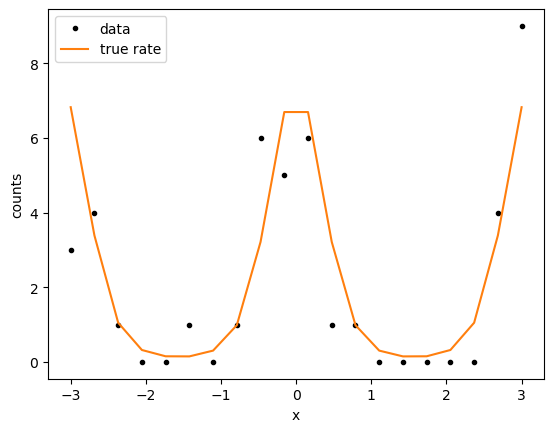

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer.autoguide import AutoNormal, AutoMultivariateNormal, AutoLowRankMultivariateNormal
from numpyro.infer import SVI, Trace_ELBO
from numpyro.optim import Adam
from tinygp import kernels, GaussianProcess

random = np.random.default_rng(203618)
x = np.linspace(-3, 3, 20)
true_log_rate = 2 * np.cos(2 * x)
y = random.poisson(np.exp(true_log_rate))
plt.plot(x, y, ".k", label="data")
plt.plot(x, np.exp(true_log_rate), "C1", label="true rate")
plt.legend(loc=2)
plt.xlabel("x")
_ = plt.ylabel("counts")

In [29]:
def model(x, y=None):
    # The parameters of the GP model
    mean = numpyro.param("mean", jnp.zeros(()))
    sigma = numpyro.param("sigma", jnp.ones(()), constraint=dist.constraints.positive)
    rho = numpyro.param("rho", 2 * jnp.ones(()), constraint=dist.constraints.positive)

    # Set up the kernel and GP objects
    kernel = sigma**2 * kernels.Matern52(rho)
    gp = GaussianProcess(kernel, x, diag=1e-5, mean=mean)

    # This parameter has shape (num_data,) and it encodes our beliefs about
    # the process rate in each bin
    log_rate = numpyro.sample("log_rate", gp.numpyro_dist())

    # Finally, our observation model is Poisson
    numpyro.sample("obs", dist.Poisson(jnp.exp(log_rate)), obs=y)


def guide(x, y=None):
    mu = numpyro.param(
        "log_rate_mu", jnp.zeros_like(x) if y is None else jnp.log(y + 1)
    )
    sigma = numpyro.param(
        "log_rate_sigma",
        jnp.ones_like(x),
        constraint=dist.constraints.positive,
    )
    numpyro.sample("log_rate", dist.Independent(dist.Normal(mu, sigma), 1))


optim = numpyro.optim.Adam(0.01)
svi = numpyro.infer.SVI(model, guide, optim, numpyro.infer.Trace_ELBO(10))
results = svi.run(jax.random.PRNGKey(55873), 3000, x, y=y, progress_bar=False)

In [30]:
results.params

{'log_rate_mu': Array([ 1.0893553 ,  1.1036181 ,  0.40279266, -0.18515097, -0.14763159,
         0.06283717,  0.06376481,  0.6146558 ,  1.5319573 ,  1.7724661 ,
         1.5772295 ,  0.80090183,  0.20694155, -0.1680791 , -0.33724606,
        -0.44809055, -0.46321428,  0.04527815,  1.224945  ,  2.1127942 ],      dtype=float32),
 'log_rate_sigma': Array([0.46143338, 0.38253996, 0.3984363 , 0.44016996, 0.43157977,
        0.3932894 , 0.44945735, 0.41292676, 0.37037915, 0.38628167,
        0.37562805, 0.41305697, 0.41744766, 0.41733006, 0.4153141 ,
        0.40905386, 0.44121724, 0.4163279 , 0.3755656 , 0.31861627],      dtype=float32),
 'mean': Array(0.76058114, dtype=float32),
 'rho': Array(0.7597576, dtype=float32),
 'sigma': Array(2.5419705, dtype=float32)}

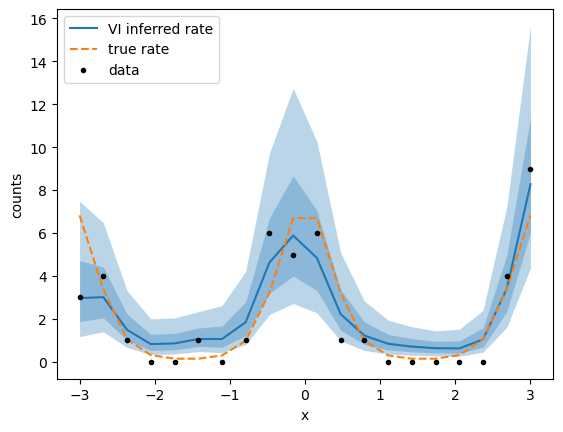

In [31]:
mu = results.params["log_rate_mu"]
sigma = results.params["log_rate_sigma"]
plt.plot(x, np.exp(mu), color="C0", label="VI inferred rate")
plt.fill_between(
    x,
    np.exp(mu - 2 * sigma),
    np.exp(mu + 2 * sigma),
    alpha=0.3,
    lw=0,
    color="C0",
)
plt.fill_between(x, np.exp(mu - sigma), np.exp(mu + sigma), alpha=0.3, lw=0, color="C0")
plt.plot(x, np.exp(true_log_rate), "--", color="C1", label="true rate")
plt.plot(x, y, ".k", label="data")
plt.legend(loc=2)
plt.xlabel("x")
_ = plt.ylabel("counts")

In [32]:


# Define the model
def model(x, y=None):
    # The parameters of the GP model
    mean = numpyro.param("mean", jnp.zeros(()))
    sigma = numpyro.param("sigma", jnp.ones(()), constraint=dist.constraints.positive)
    rho = numpyro.param("rho", 2 * jnp.ones(()), constraint=dist.constraints.positive)

    # Set up the kernel and GP objects
    kernel = sigma**2 * kernels.Matern52(rho)
    gp = GaussianProcess(kernel, x, diag=1e-5, mean=mean)

    # Latent function sampled from the GP prior
    log_rate = numpyro.sample("log_rate", gp.numpyro_dist())

    # Poisson likelihood for observed data
    numpyro.sample("obs", dist.Poisson(jnp.exp(log_rate)), obs=y)

# Use AutoGuide for the guide
guide = AutoLowRankMultivariateNormal(model, rank=5)

# Set up optimizer and SVI
optim = Adam(0.01)
svi = SVI(model, guide, optim, Trace_ELBO(10))

# Run inference
results = svi.run(jax.random.PRNGKey(55873), 3000, x, y=y, progress_bar=False)


In [33]:
results.params

{'auto_cov_factor': Array([[ 1.06141873e-01, -6.64886892e-01, -2.18529388e-01,
         -3.18458438e-01, -2.59673476e-01],
        [-3.09331924e-01, -3.11177182e+00, -4.42852199e-01,
          2.54446387e-01, -2.52487529e-02],
        [-9.91562724e-01, -2.24748397e+00,  6.77345037e-01,
          2.12448716e+00,  6.32275224e-01],
        [-4.49979663e-01, -3.78130198e-01,  6.41482592e-01,
          1.31287158e+00,  4.40874457e-01],
        [ 2.93170824e-03,  1.24974281e-01,  1.43625155e-01,
          2.57236898e-01,  7.21371993e-02],
        [ 7.22586662e-02,  2.75705624e-02, -6.37513548e-02,
         -1.15852080e-01, -1.98016539e-02],
        [-1.75070334e-02, -2.33717971e-02, -3.73783670e-02,
          4.96404339e-03,  7.77606573e-03],
        [-3.58793028e-02,  3.81919352e-04,  5.49837500e-02,
          8.13619886e-03,  5.15903055e-04],
        [-1.13848718e-02, -6.22587185e-03, -1.25832157e-02,
         -4.03534883e-04,  1.55336121e-02],
        [-2.38104258e-02, -3.63697298e-03,  1

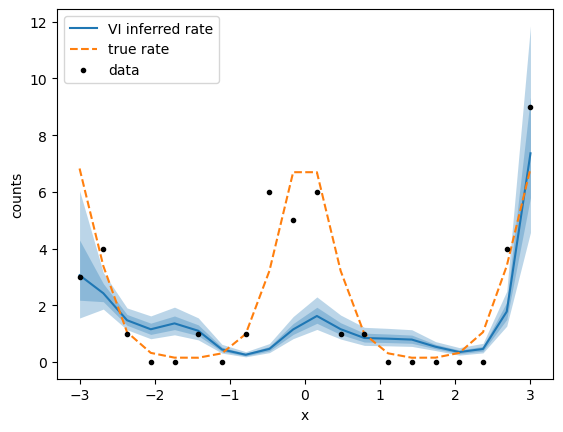

In [34]:
mu = results.params["auto_loc"]
sigma = results.params["auto_scale"]
plt.plot(x, np.exp(mu), color="C0", label="VI inferred rate")
plt.fill_between(
    x,
    np.exp(mu - 2 * sigma),
    np.exp(mu + 2 * sigma),
    alpha=0.3,
    lw=0,
    color="C0",
)
plt.fill_between(x, np.exp(mu - sigma), np.exp(mu + sigma), alpha=0.3, lw=0, color="C0")
plt.plot(x, np.exp(true_log_rate), "--", color="C1", label="true rate")
plt.plot(x, y, ".k", label="data")
plt.legend(loc=2)
plt.xlabel("x")
_ = plt.ylabel("counts")

In [37]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from tinygp import kernels, GaussianProcess
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO
from numpyro.optim import Adam
from scipy.integrate import quad_vec


# Rotation matrix for Euler angles
def rotation_matrix(alpha, beta, gamma):
    Rz_alpha = jnp.array([
        [jnp.cos(alpha), -jnp.sin(alpha), 0],
        [jnp.sin(alpha),  jnp.cos(alpha), 0],
        [0, 0, 1]
    ])
    Rx_beta = jnp.array([
        [1, 0, 0],
        [0, jnp.cos(beta), -jnp.sin(beta)],
        [0, jnp.sin(beta),  jnp.cos(beta)]
    ])
    Rz_gamma = jnp.array([
        [jnp.cos(gamma), -jnp.sin(gamma), 0],
        [jnp.sin(gamma),  jnp.cos(gamma), 0],
        [0, 0, 1]
    ])
    return Rz_alpha @ Rx_beta @ Rz_gamma


# Rotate galaxy coordinates to sky-plane coordinates
def rotate_to_sky(x_gal, y_gal, z_gal, alpha, beta, gamma):
    R = rotation_matrix(alpha, beta, gamma)
    coords = jnp.stack([x_gal, y_gal, z_gal], axis=-1)
    rotated_coords = coords @ R.T  # Apply rotation
    return rotated_coords[..., 0], rotated_coords[..., 1], rotated_coords[..., 2]


# Define the density function
def rho(x, y, z, e, p, q, rho0, s, a, b):
    r = jnp.sqrt(x**2 + y**2 + z**2)
    m = ((jnp.abs(x)**(2 - e) + (jnp.abs(y) / p)**(2 - e) + (jnp.abs(z) / q)**(2 - e)))**(1 / (2 - e))
    den = rho0 / ((m / s)**a * (1 + (m / s))**(b - a))
    return den / (p * q)


def model(image, grid_x, grid_y, rho_obs=None):
    # Sample Euler angles
    alpha = numpyro.param("alpha", 0.0, constraint=dist.constraints.interval(0.0, 2 * jnp.pi))
    beta = numpyro.param("beta", jnp.pi / 4, constraint=dist.constraints.interval(0.0, jnp.pi))
    gamma = numpyro.param("gamma", 0.0, constraint=dist.constraints.interval(0.0, 2 * jnp.pi))

    # Define z-grid for summation
    z_grid = jnp.linspace(-10, 10, 100)

    # Rotate coordinates to galaxy's intrinsic frame
    x_gal, y_gal, z_gal = rotate_to_sky(grid_x, grid_y, z_grid[:, None, None], alpha, beta, gamma)

    # Convert grid to radial distance r
    r_gal = jnp.sqrt(x_gal**2 + y_gal**2 + z_gal**2)

    # Latent GP for p(r)
    sigma_p = numpyro.param("sigma_p", jnp.ones(()), constraint=dist.constraints.positive)
    length_scale_p = numpyro.param("length_scale_p", jnp.ones(()), constraint=dist.constraints.positive)
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gal, diag=1e-5, mean=0.0)
    f_p = numpyro.sample("f_p", gp_p.numpyro_dist())
    p = 0.1 + 0.9 * jax.nn.sigmoid(f_p)  # Constrain p to (0.1, 1)

    # Constant parameters
    rho0 = numpyro.param("rho0", 1.0, constraint=dist.constraints.positive)
    s = numpyro.param("s", 1.0, constraint=dist.constraints.positive)
    a = numpyro.param("a", 1.0, constraint=dist.constraints.positive)
    b = numpyro.param("b", 2.0, constraint=dist.constraints.positive)

    # Parameters for q and e
    q = numpyro.param("q", 0.7, constraint=dist.constraints.interval(0.1, 1.0))
    e = numpyro.param("e", 0.0, constraint=dist.constraints.interval(-1.0, 1.0))

    # Compute the surface brightness
    density = rho(x_gal, y_gal, z_gal, p, rho0, s, a, b, e, q)
    brightness = jnp.sum(density, axis=0) * (z_grid[1] - z_grid[0])  # Scale by grid spacing

    # Observation model
    numpyro.sample("brightness_obs", dist.Normal(brightness, 0.1), obs=image)




In [39]:
import numpy as np

# Create dummy data with summation along z
def create_dummy_image_sum(grid_x, grid_y, alpha, beta, gamma, p_func, rho0, s, a, b, e=0.0, q=0.7):
    # Define z-grid for summation
    z_grid = jnp.linspace(-10, 10, 100)

    # Rotate coordinates
    x_gal, y_gal, z_gal = rotate_to_sky(grid_x, grid_y, z_grid[:, None, None], alpha, beta, gamma)

    # Compute radial distance in galaxy coordinates
    r_gal = jnp.sqrt(x_gal**2 + y_gal**2 + z_gal**2)

    # Evaluate p(r)
    p = p_func(r_gal)

    # Compute density
    density = rho(x_gal, y_gal, z_gal, p, rho0, s, a, b, e=e, q=q)

    # Sum along the z-axis to get surface brightness
    brightness = jnp.sum(density, axis=0) * (z_grid[1] - z_grid[0])  # Scale by grid spacing

    return brightness



# Define latent functions
#def e_func(r):
#    return jnp.tanh(-0.5 * r)

def p_func(r):
    return 0.1 + 0.9 * jnp.exp(-0.2 * r)

#def q_func(r):
#    return 0.1 + 0.9 * jnp.exp(-0.3 * r)

# True parameters
alpha_true = 0.5  # Rotation angle alpha
beta_true = 0.4   # Rotation angle beta
gamma_true = 0.3  # Rotation angle gamma
rho0_true = 1.0
s_true = 1.0
a_true = 1.0
b_true = 2.0
e_true = -0.5
q_true = 0.8

# Create a dummy image
grid_x, grid_y = jnp.meshgrid(jnp.linspace(-1, 1, 32), jnp.linspace(-1, 1, 32))
dummy_image = create_dummy_image_sum(grid_x, grid_y, alpha_true, beta_true, gamma_true, p_func, rho0_true, s_true, a_true, b_true, e=e_true, q=q_true)

# Add noise to simulate observations
obs_image = dummy_image + np.random.normal(0, 0.1, dummy_image.shape)

# Train the model on the dummy observation
results = svi.run(jax.random.PRNGKey(42), 2000, obs_image, grid_x, grid_y)

# Extract inferred parameters
inferred_params = {name: results.params[name] for name in results.params.keys()}

print("True Parameters:")
print(f"alpha: {alpha_true}, beta: {beta_true}, gamma: {gamma_true}")
print(f"rho0: {rho0_true}, s: {s_true}, a: {a_true}, b: {b_true}")
print(f"e: {e_true}, q: {q_true}")

print("\nInferred Parameters:")
for param, value in inferred_params.items():
    print(f"{param}: {value}")


ValueError: All input arrays must have the same shape.